<a href="https://colab.research.google.com/github/Sharon972/me/blob/dataton2024/DATATON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis del dataset de Registros delictivos del Observatorio Regional de Seguridad Ciudadana en la Provincia Constitucional del Callao** <br>
Link a dataset -----> [REGISTROS DELICTIVOS PROV. CALLAO](https://expresateperu.datosabiertos.gob.pe/dataset/registros-delictivos-del-observatorio-regional-de-seguridad-ciudadana-en-la-provincia-0#{})

*Por: <br>Lucy Angie Sharon Flores Marcos [link a linkdln](https://www.linkedin.com/in/lucy-flores-marcos-a32b26234)<br>  Maycol Jhunior Meza Roque [link a linkdln](https://www.linkedin.com/in/mychael29/)*

## **1. INTRODUCCIÓN**

El análisis se llevó a cabo utilizando datos proporcionados por el Gobierno Regional del Callao correspondientes a febrero de 2024. Durante este análisis, se identificó que los delitos con mayor número de denuncias fueron el de violencia contra la mujer y la familia, con 937 casos reportados, seguidos por el robo con 320 denuncias, y el hurto con 236 denuncias. Según la Policía Nacional del Perú, entre enero y el 4 de agosto de 2023, se registraron un total de 13,469 denuncias por robos y hurto agravado. Es alarmante destacar que, en Lima Metropolitana y Callao, se reportan tres delitos de hurto cada cuatro horas (https://www.infobae.com/peru/2023/08/05/13-mil-denuncias-por-robos-y-hurto-agravado-en-lo-que-va-del-2023-segun-la-policia-nacional/). Este análisis, junto con los datos reportados, demuestra que los delitos de robo y hurto son los principales factores que ponen en riesgo la seguridad ciudadana en las calles.

El enfoque se centra entonces en el Tipo de delito contra el patrimonio y los subtipos correspondientes de robo y hurto, la diferencia entre estos dos radica en que mientras el robo afecta tanto al patrimonio como a la integridad y libertad de la víctima, el hurto solo daña el patrimonio de la persona. Esto de acuerdo al Código Penal peruano, el cual establece regulaciones y sanciones ante estos delitos contra el patrimonio.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## **2. DESCRIPCIÓN Y LIMPIEZA DE LOS DATOS**

El periodo de análisis que se identificó en todo el dataset brindado corresponde al mes de febrero de 2021; además se identificaron como variables clave a : <br><br>TIPO: Clasificación general de los presuntos delitos acontecidos. <br>SUBTIPO: Clasificación de los tipos de delitos.<br>DISTRITO: Distrito donde se da el hecho presuntamente delictivo, <br>LONGITUD: Coordenada Geográfica de longitud en grados centesimales, <br>LATITUD: Coordenada Geográfica de latitud en grados centesimales.<br>MODALIDAD: Clasificación de los subtipos de delitos.<br><br>Este dataset posee 2643 filas y 26 variables o columnas, de las cuales se posee 2639 registros.
<br>
Fue elegido por su utilidad para resolver Objetivo de Desarrollo Sostenible (ODS) Nro. 11 que tiene como objeto el "Lograr que las ciudades y los asentamientos humanos sean inclusivos, seguros, resilientes y sostenibles". Específicamente contribuye con el indicador 11.7.1: "Proporción de áreas urbanas públicas accesibles, seguras y libres de violencia para todos, en especial para mujeres y niños." y por el hecho de que estos delitos son unas de las preocupaciones más grandes de la población del Callao citando a (https://www.tvperu.gob.pe/noticias/locales/callao-la-inseguridad-ciudadana-es-el-enemigo-numero-1-del-primer-puerto)

In [ ]:
#Cargo la data cruda y visualizo de la dimensión y cantidad de columnas
datacruda = pd.read_csv('/content/DATASET_SEGURIDAD_CALLAO_FEBRERO2024_0.csv', sep = ';')
print('Dimensión de data: ', datacruda.shape)
datacruda.columns

Dimensión de data:  (2643, 26)


Index(['FECHA_CORTE', 'FECHA_REGISTRO', 'ID_DOC_DENUNCIA', 'UBIGEO',
       'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'TIPO_DE_DENUNCIA',
       'SITUACION_DENUNCIA', 'TIPO', 'SUBTIPO', 'MODALIDAD', 'FECHA_HECHO',
       'HORA_HECHO', 'UBICACION', 'DESCRIPCION', 'FECHA_NACIMIENTO',
       'EDAD_PERSONA', 'SEXO', 'ESTADO_CIVIL', 'GRADO_INSTRUCCION',
       'OCUPACION', 'PAIS_NATAL', 'MES', 'LONGITUD', 'LATITUD'],
      dtype='object')

In [ ]:
#Veo el tipo de dato de cada variable
datacruda.dtypes

,0
FECHA_CORTE,int64
FECHA_REGISTRO,int64
ID_DOC_DENUNCIA,object
UBIGEO,int64
DEPARTAMENTO,object
PROVINCIA,object
DISTRITO,object
TIPO_DE_DENUNCIA,object
SITUACION_DENUNCIA,object
TIPO,object


In [ ]:
#Separo la data de MES (int64) en dos columnas de año y mes
data = datacruda.copy()
data['Año'] = datacruda['MES'].astype(str).str[:4]
data['Mes'] = datacruda['MES'].astype(str).str[4:]
data.head()

,FECHA_CORTE,FECHA_REGISTRO,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,SITUACION_DENUNCIA,TIPO,...,SEXO,ESTADO_CIVIL,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,MES,LONGITUD,LATITUD,Año,Mes
0,20240425,20240226,4e35831afdd9aa1958807a7b32ea5b53a26aa74d1556d5...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,PENDIENTE,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.115782,-12.005028,2024,02
1,20240425,20240221,7ccf55ed76f62bc29e46f082caa7e57c289dc59bded9d8...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.154571,-11.844027,2024,02
2,20240425,20240210,fed71611056418d9ebbda0717e8252554c85b3b08f34fa...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.126113,-12.051164,2024,02
3,20240425,20240220,7d920f96de74cf295cbbb4da54057db724c98421ffa0a1...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,MASCULINO,SOLTERO(A),NO INDICA,VIGILANTE,PERU,202402,-77.129483,-11.951019,2024,02
4,20240425,20240223,060b191856ee7bf4feb80322d9c04ff36bbc99eaa75075...,70101,CALLAO,CALLAO,CALLAO,ACTA DE INTERVENCION,RESUELTA,PATRIMONIO (DELITO),...,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.125383,-12.051164,2024,02


In [ ]:
#Elimino la columna 'MES'
data = data.drop(['MES'], axis = 1)
data.head()

,FECHA_CORTE,FECHA_REGISTRO,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,SITUACION_DENUNCIA,TIPO,...,EDAD_PERSONA,SEXO,ESTADO_CIVIL,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,LONGITUD,LATITUD,Año,Mes
0,20240425,20240226,4e35831afdd9aa1958807a7b32ea5b53a26aa74d1556d5...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,PENDIENTE,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,33,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,-77.115782,-12.005028,2024,02
1,20240425,20240221,7ccf55ed76f62bc29e46f082caa7e57c289dc59bded9d8...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,39,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,-77.154571,-11.844027,2024,02
2,20240425,20240210,fed71611056418d9ebbda0717e8252554c85b3b08f34fa...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,30,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,-77.126113,-12.051164,2024,02
3,20240425,20240220,7d920f96de74cf295cbbb4da54057db724c98421ffa0a1...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,38,MASCULINO,SOLTERO(A),NO INDICA,VIGILANTE,PERU,-77.129483,-11.951019,2024,02
4,20240425,20240223,060b191856ee7bf4feb80322d9c04ff36bbc99eaa75075...,70101,CALLAO,CALLAO,CALLAO,ACTA DE INTERVENCION,RESUELTA,PATRIMONIO (DELITO),...,28,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,-77.125383,-12.051164,2024,02


In [ ]:
#Visualizo valores faltantes
datacruda.isnull().sum()

,0
FECHA_CORTE,0
FECHA_REGISTRO,0
ID_DOC_DENUNCIA,0
UBIGEO,0
DEPARTAMENTO,0
PROVINCIA,0
DISTRITO,0
TIPO_DE_DENUNCIA,0
SITUACION_DENUNCIA,0
TIPO,0


In [ ]:
#Veo a que filas pertenecen los valores faltantes
datacruda[datacruda.isnull().any(axis=1)]

,FECHA_CORTE,FECHA_REGISTRO,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,SITUACION_DENUNCIA,TIPO,...,FECHA_NACIMIENTO,EDAD_PERSONA,SEXO,ESTADO_CIVIL,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,MES,LONGITUD,LATITUD
119,20240425,20240208,886dc00edba8839da0e306e46fc89e0e4f4e2b2017e415...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,PENDIENTE,LIBERTAD (DELITO),...,19830326,40,FEMENINO,SOLTERO(A),NO INDICA,INDEPENDIENTE,PERU,202402,NaN,NaN
683,20240425,20240226,67b3283d99b162b6770706c5fbca592142db18096a72cb...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,PATRIMONIO (DELITO),...,19940211,30,FEMENINO,SOLTERO(A),NO INDICA,ADMINISTRADOR,PERU,202402,NaN,NaN
1467,20240425,20240207,159138bfb2da8a60c081396079e856daff18b9d4fcc188...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,PATRIMONIO (DELITO),...,19800417,43,FEMENINO,SOLTERO(A),SECUNDARIA,NO INDICA,PERU,202402,NaN,NaN
2496,20240425,20240217,97bfb20b3e2503b79efd177a708ff0342649697b8be6af...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,PENDIENTE,LEY 30096 DELITOS INFORMATICOS MODIFICADA POR...,...,20041022,19,MASCULINO,SOLTERO(A),NO INDICA,OBRERO,PERU,202402,NaN,NaN


In [ ]:
#4 denuncias en febrero del 2024
#Elimino las filas en donde se tienen datos faltantes de coordenadas
data = data.dropna()
data.isnull().sum()

,0
FECHA_CORTE,0
FECHA_REGISTRO,0
ID_DOC_DENUNCIA,0
UBIGEO,0
DEPARTAMENTO,0
PROVINCIA,0
DISTRITO,0
TIPO_DE_DENUNCIA,0
SITUACION_DENUNCIA,0
TIPO,0


In [ ]:
data.Mes.unique()

array(['02'], dtype=object)

In [ ]:
data.TIPO.unique()

array(['LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULNERABLES',
       'PATRIMONIO (DELITO)',
       'LEY 30096 DELITOS INFORMATICOS  MODIFICADA POR LA LEY 30171',
       'SEGURIDAD PUBLICA (DELITO)', 'LIBERTAD (DELITO)',
       'ADMINISTRACION PUBLICA (DELITO)',
       'VIDA  EL CUERPO Y LA SALUD (DELITO)', 'FAMILIA (DELITO)',
       'DERECHOS INTELECTUALES (DELITO)', 'FE PUBLICA (DELITO)',
       'TRANQUILIDAD PUBLICA (DELITO)'], dtype=object)

In [ ]:
#De la columna FECHA_CORTE que está en formato YYYYMMDD modifico de tal manera que
#los días se guarden en una nueva columna
data['Dia_Corte'] = data['FECHA_CORTE'].astype(str).str[6:]
data['Dia_Registro'] = data['FECHA_REGISTRO'].astype(str).str[6:]
data.head()

,FECHA_CORTE,FECHA_REGISTRO,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,SITUACION_DENUNCIA,TIPO,...,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,MES,LONGITUD,LATITUD,Año,Mes,Dia_Corte,Dia_Registro
0,20240425,20240226,4e35831afdd9aa1958807a7b32ea5b53a26aa74d1556d5...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,PENDIENTE,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,NO INDICA,NO INDICA,PERU,202402,-77.115782,-12.005028,2024,02,25,26
1,20240425,20240221,7ccf55ed76f62bc29e46f082caa7e57c289dc59bded9d8...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,NO INDICA,NO INDICA,PERU,202402,-77.154571,-11.844027,2024,02,25,21
2,20240425,20240210,fed71611056418d9ebbda0717e8252554c85b3b08f34fa...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,NO INDICA,NO INDICA,PERU,202402,-77.126113,-12.051164,2024,02,25,10
3,20240425,20240220,7d920f96de74cf295cbbb4da54057db724c98421ffa0a1...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,RESUELTA,LEY DE VIOLENCIA CONTRA LA MUJER Y GRUPOS VULN...,...,NO INDICA,VIGILANTE,PERU,202402,-77.129483,-11.951019,2024,02,25,20
4,20240425,20240223,060b191856ee7bf4feb80322d9c04ff36bbc99eaa75075...,70101,CALLAO,CALLAO,CALLAO,ACTA DE INTERVENCION,RESUELTA,PATRIMONIO (DELITO),...,NO INDICA,NO INDICA,PERU,202402,-77.125383,-12.051164,2024,02,25,23


In [ ]:
#Muevo las columnas nuevas de Dia_Corte y Dia_Registro de tal manera
#que se encuentren en la tercera y cuarta columna respectivamente de la data
data.insert(2, 'Dia_Corte', data.pop('Dia_Corte'))
data.insert(3, 'Dia_Registro', data.pop('Dia_Registro'))
data.head(2)

,FECHA_CORTE,FECHA_REGISTRO,Dia_Corte,Dia_Registro,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,...,SEXO,ESTADO_CIVIL,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,MES,LONGITUD,LATITUD,Año,Mes
0,20240425,20240226,25,26,4e35831afdd9aa1958807a7b32ea5b53a26aa74d1556d5...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,...,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.115782,-12.005028,2024,02
1,20240425,20240221,25,21,7ccf55ed76f62bc29e46f082caa7e57c289dc59bded9d8...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,...,MASCULINO,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.154571,-11.844027,2024,02


## **3. ANÁLISIS EXPLORATORIO**

3.1 ANALÍSIS DE VARIABLES

In [ ]:
data.columns

Index(['FECHA_CORTE', 'FECHA_REGISTRO', 'Dia_Corte', 'Dia_Registro',
       'ID_DOC_DENUNCIA', 'UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
       'TIPO_DE_DENUNCIA', 'SITUACION_DENUNCIA', 'TIPO', 'SUBTIPO',
       'MODALIDAD', 'FECHA_HECHO', 'HORA_HECHO', 'UBICACION', 'DESCRIPCION',
       'FECHA_NACIMIENTO', 'EDAD_PERSONA', 'SEXO', 'ESTADO_CIVIL',
       'GRADO_INSTRUCCION', 'OCUPACION', 'PAIS_NATAL', 'MES', 'LONGITUD',
       'LATITUD', 'Año', 'Mes'],
      dtype='object')

Ya que se tiene identificadas las variables y limpia la data se pasa al análisis espacial.

3.2 ANÁLISIS ESPACIAL

Este análisis sirvió para poder exportar la información para poder visualizar en un software GIS como Qgis.

In [ ]:
import geopandas as gpd

In [ ]:
#agrego una columna geometry en base a las columnas de LONGITUD y LATITUD

data['geometry'] = gpd.points_from_xy(data.LONGITUD, data.LATITUD)

In [ ]:
gdf = gpd.GeoDataFrame(data, geometry = 'geometry', crs = 'EPSG:4326')

In [ ]:
#En una nueva columna que guarde la geometría almaceno los las coordenadas de latitud
#y longitud pero en UTM
gdf.crs
gdfUTM = gdf.to_crs('EPSG:32718')
gdfUTM.head(2)

,FECHA_CORTE,FECHA_REGISTRO,Dia_Corte,Dia_Registro,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,...,ESTADO_CIVIL,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,MES,LONGITUD,LATITUD,Año,Mes,geometry
0,20240425,20240226,25,26,4e35831afdd9aa1958807a7b32ea5b53a26aa74d1556d5...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,...,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.115782,-12.005028,2024,02,POINT (269634.014 8672005.373)
1,20240425,20240221,25,21,7ccf55ed76f62bc29e46f082caa7e57c289dc59bded9d8...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,...,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.154571,-11.844027,2024,02,POINT (265270.363 8689787.304)


In [ ]:
#Renombro la columna geometry a geometry_UTM
gdfUTM = gdfUTM.rename(columns = {'geometry': 'geometry_UTM'})
gdfUTM.head(2)

,FECHA_CORTE,FECHA_REGISTRO,Dia_Corte,Dia_Registro,ID_DOC_DENUNCIA,UBIGEO,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO_DE_DENUNCIA,...,ESTADO_CIVIL,GRADO_INSTRUCCION,OCUPACION,PAIS_NATAL,MES,LONGITUD,LATITUD,Año,Mes,geometry_UTM
0,20240425,20240226,25,26,4e35831afdd9aa1958807a7b32ea5b53a26aa74d1556d5...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,...,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.115782,-12.005028,2024,02,POINT (269634.014 8672005.373)
1,20240425,20240221,25,21,7ccf55ed76f62bc29e46f082caa7e57c289dc59bded9d8...,70101,CALLAO,CALLAO,CALLAO,DENUNCIA,...,SOLTERO(A),NO INDICA,NO INDICA,PERU,202402,-77.154571,-11.844027,2024,02,POINT (265270.363 8689787.304)


In [ ]:
#Creo dos columnas para almacenar el Norte y el Este en UTM
# Extraer las coordenadas X e Y
gdf_UTM = gdfUTM.copy()
gdf_UTM['NORTE_UTM'] = gdf_UTM['geometry_UTM'].apply(lambda geom: geom.y)
gdf_UTM['ESTE_UTM'] = gdf_UTM['geometry_UTM'].apply(lambda geom: geom.x)

#Los convierto a float 64
gdf_UTM['NORTE_UTM'] = gdf_UTM['NORTE_UTM'].astype('float64')
gdf_UTM['ESTE_UTM'] = gdf_UTM['ESTE_UTM'].astype('float64')
# Verificar el resultado

pd.set_option('display.float_format', '{:.6f}'.format)
print(gdf_UTM[['geometry_UTM', 'NORTE_UTM', 'ESTE_UTM']])

                        geometry_UTM      NORTE_UTM      ESTE_UTM
0     POINT (269634.014 8672005.373) 8672005.372815 269634.014017
1     POINT (265270.363 8689787.304) 8689787.304345 265270.363045
2     POINT (268548.191 8666891.859) 8666891.859356 268548.191019
3     POINT (268095.481 8677969.912) 8677969.911884 268095.481420
4     POINT (268627.645 8666892.475) 8666892.475114 268627.645494
...                              ...            ...           ...
2638  POINT (271364.417 8669989.045) 8669989.044971 271364.417491
2639  POINT (272206.226 8669670.333) 8669670.333234 272206.226011
2640  POINT (270475.705 8666770.827) 8666770.827008 270475.705159
2641  POINT (272161.990 8670714.080) 8670714.079933 272161.989740
2642  POINT (271835.454 8669889.279) 8669889.278638 271835.453743

[2639 rows x 3 columns]


In [ ]:
#Convierto a geojson
gdf_UTM = gdfUTM.rename(columns = {'geometry_UTM': 'geometry'})
geojson_str = gdf_UTM.to_json()

with open("delitos_Callao.geojson", "w") as f:
    f.write(geojson_str)

#Este archivo geojson servirá para poder trabajar la data georeferenciada en Qgis.

A continuacíón se visualiza el mapa de calor (heatmap) realizado en software GIS.

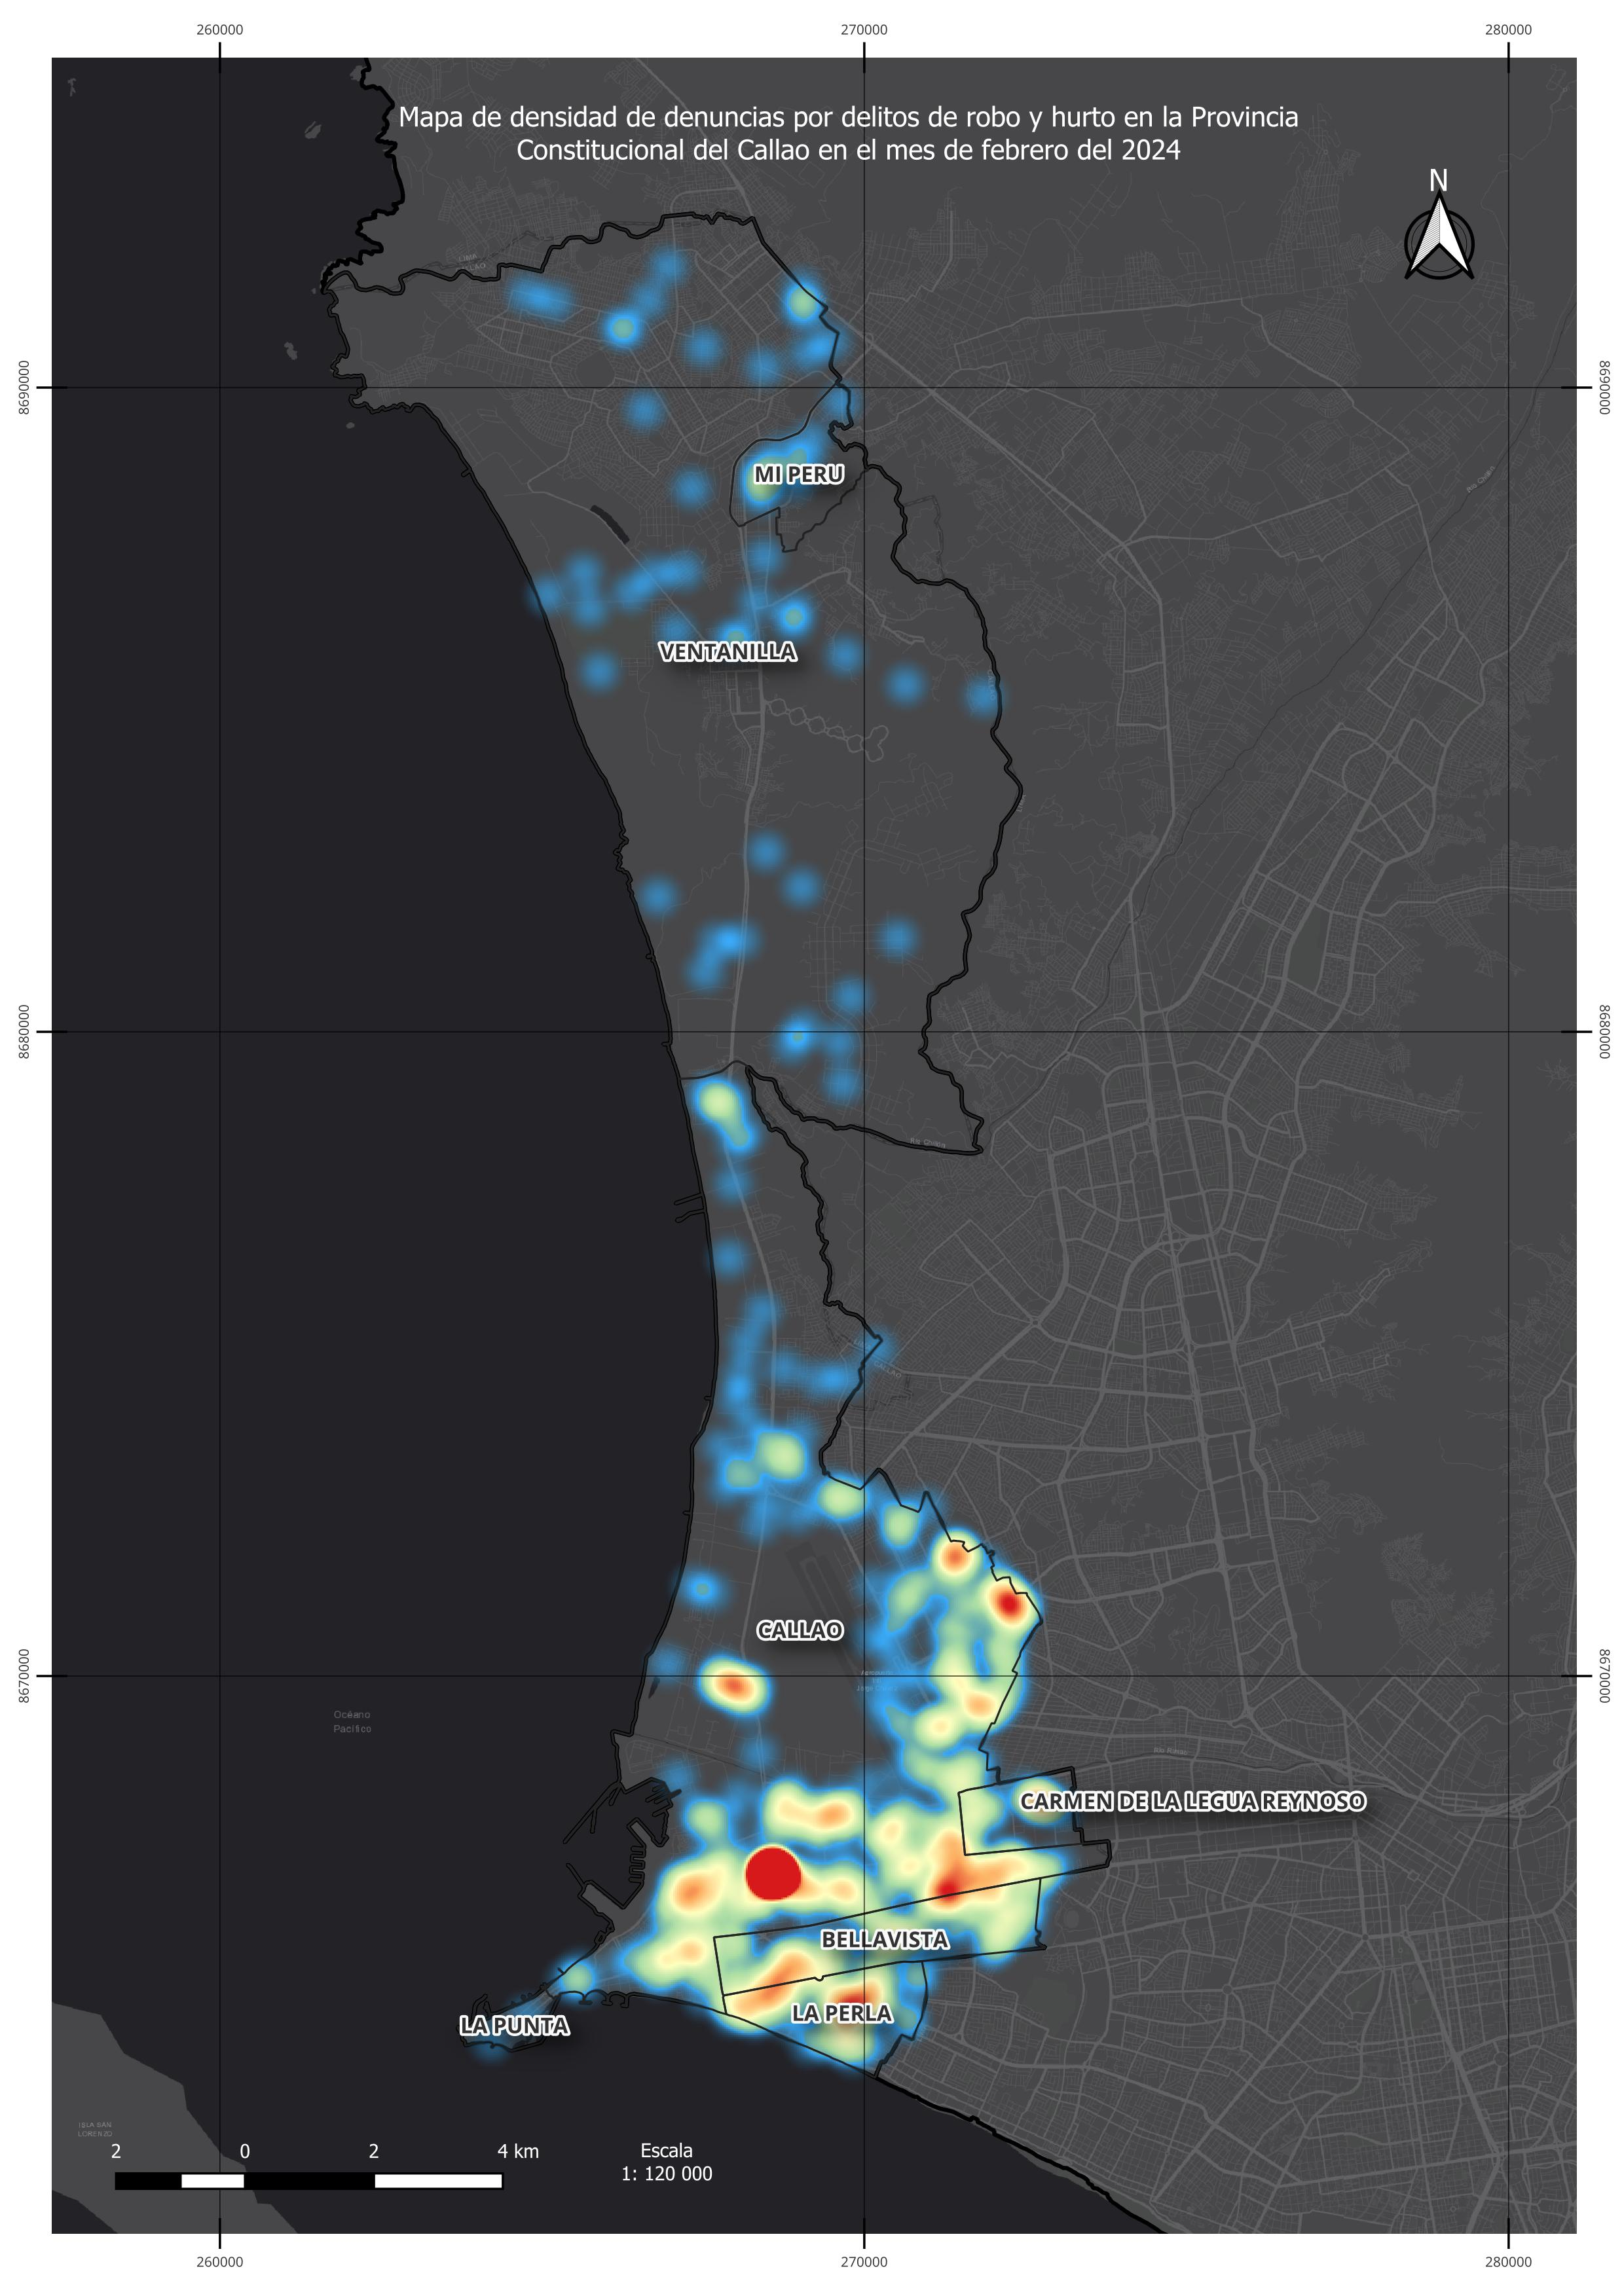

3.3 ANÁLISIS DE DATOS

In [ ]:
#Visualizo los nombres de las columnas
gdf_UTM.columns

Index(['FECHA_CORTE', 'FECHA_REGISTRO', 'Dia_Corte', 'Dia_Registro',
       'ID_DOC_DENUNCIA', 'UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
       'TIPO_DE_DENUNCIA', 'SITUACION_DENUNCIA', 'TIPO', 'SUBTIPO',
       'MODALIDAD', 'FECHA_HECHO', 'HORA_HECHO', 'UBICACION', 'DESCRIPCION',
       'FECHA_NACIMIENTO', 'EDAD_PERSONA', 'SEXO', 'ESTADO_CIVIL',
       'GRADO_INSTRUCCION', 'OCUPACION', 'PAIS_NATAL', 'MES', 'LONGITUD',
       'LATITUD', 'Año', 'Mes', 'geometry'],
      dtype='object')

In [ ]:
#Cambio el nombre del SUBTIPO LEY PARA PREVENIR SANCIONAR Y ERRADICAR LA VIOLENCIA CONTRA LAS MUJERES Y LOS INTEGRANTES DEL GRUPO FAMILIAR (LEY NRO 30364) POR VIOLENCIAS CONTRA LA MUJER Y FAMILIARES

data2 = gdf_UTM.copy()
data2['SUBTIPO'] = data2['SUBTIPO'].str.replace(
    'LEY PARA PREVENIR   SANCIONAR Y ERRADICAR LA VIOLENCIA CONTRA LAS MUJERES Y LOS INTEGRANTES DEL GRUPO FAMILIAR (LEY NRO 30364)',
    'VIOLENCIAS CONTRA LA MUJER Y FAMILIARES'
)


# Verifico los primeros registros para asegurarse de que el cambio se aplicó
print(data2['SUBTIPO'].unique())

['VIOLENCIAS CONTRA LA MUJER Y FAMILIARES' 'ROBO' 'HURTO'
 'DELITOS INFORMATICOS CONTRA EL PATRIMONIO' 'PELIGRO COMUN'
 'VIOLACION DE LA LIBERTAD SEXUAL' 'ESTAFA Y OTRAS DEFRAUDACIONES'
 'COMETIDOS POR PARTICULARES' 'DAÑOS' 'HOMICIDIO' 'LESIONES'
 'COMETIDOS POR FUNCIONARIOS PUBLICOS' 'EXTORSION' 'SALUD PUBLICA'
 'VIOLACION DE LA LIBERTAD PERSONAL' 'ATENTADOS CONTRA LA PATRIA POTESTAD'
 'RECEPTACION' 'PROPIEDAD INDUSTRIAL' 'DISPOSICIONES COMUNES'
 'FALSIFICACION DE DOCUMENTOS EN GENERAL' 'APROPIACION ILICITA'
 'MEDIOS DE TRANSPORTE  COMUNICACIONES Y OTROS SERVICIOS PUBLICOS'
 'DELITOS INFORMATICOS CONTRA LA FE PUBLICA' 'PAZ PUBLICA'
 'EXPOSICION A PELIGRO O ABANDONO DE PERSONAS EN PELIGRO'
 'VIOLACION DE DOMICILIO' 'VIOLACION DE LA INTIMIDAD' 'USURPACION'
 'FALSIFICACION DE SELLOS  TIMBRES Y MARCAS OFICIALES'
 'CONTRA LA INTIMIDAD Y EL SECRETO DE LAS COMUNICACIONES'
 'CONTRA LA HUMANIDAD' 'ABORTO']


In [ ]:
#Agrupo or subtipo de denuncia.
data2.SUBTIPO.value_counts().to_frame().style.background_gradient(cmap = 'BuPu')

,count
SUBTIPO,
VIOLENCIAS CONTRA LA MUJER Y FAMILIARES,937
HURTO,320
ROBO,236
PELIGRO COMUN,206
RECEPTACION,131
FALSIFICACION DE DOCUMENTOS EN GENERAL,109
ESTAFA Y OTRAS DEFRAUDACIONES,95
DELITOS INFORMATICOS CONTRA EL PATRIMONIO,93
LESIONES,80


En la tabla superior se puede visualizar que las denuncias pertenecientes al subtipo de violencia contra la mujer y familiares suman 937, las denuncias de delitos de hurto suman 320 y las denuncias por delitos de robo suman 236.

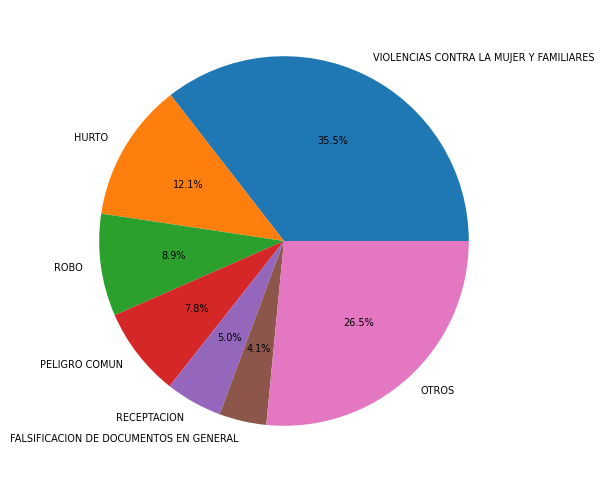

In [ ]:
# Calculo los valores de cada subgrupo
subtipo_counts = data2['SUBTIPO'].value_counts()

# Defino un umbral para las categorías poco frecuentes (por ejemplo, menos del 5%)
threshold = 0.04 * subtipo_counts.sum()

# Agrupo las categorías que están por debajo del umbral
otros = subtipo_counts[subtipo_counts < threshold].sum()
subtipos_filtrados = subtipo_counts[subtipo_counts >= threshold]
subtipos_filtrados['OTROS'] = otros

# Grafico el pie chart con las categorías agrupadas
plt.figure(figsize=(10, 6))
subtipos_filtrados.plot.pie(autopct='%1.1f%%',textprops={'fontsize': 7})
plt.ylabel('')  # Elimina el label de 'count'
plt.show()

Para una mejor visualización con respecto al total de denuncias por subtipo, el delito de violencia contra la mujer y familiares ocupa un 35.5%, los delitos de hurto y robo ocupan el 12.1% y 8.9% respectivamente. Esto seguido por los delitos de peligro común con 7.8%, receptación con un 5% y falsificación de documentos en general con un 4.1%.

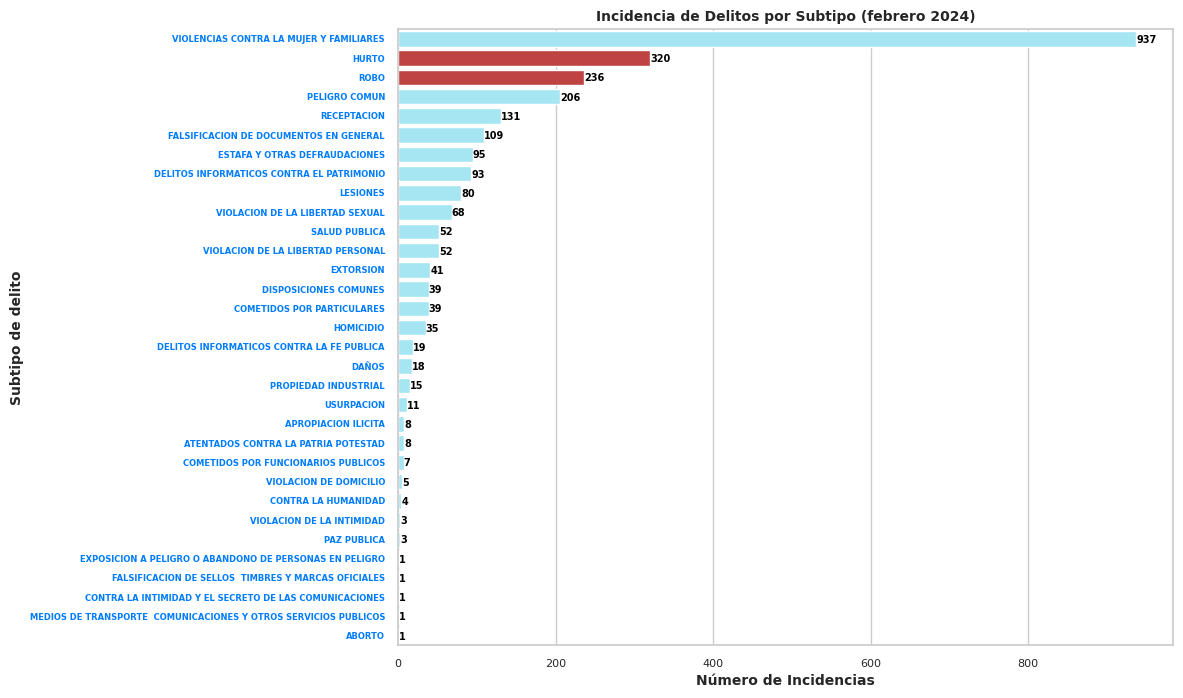

In [ ]:
# Asegúrate de que seaborn esté configurado para un estilo atractivo
sns.set(style="whitegrid")

# Obtener los valores de conteo para cada subtipo
subtipo_counts = data2.SUBTIPO.value_counts()

# Crear un DataFrame temporal con los valores y subtipos
df_temp = subtipo_counts.reset_index()
df_temp.columns = ['SUBTIPO', 'count']

# Crear una paleta de colores, destacando 'ROBO' y 'HURTO'
colors = ['#d32f2f' if (x == 'ROBO' or x == 'HURTO') else '#99eeff' for x in df_temp['SUBTIPO']]

# Crear el gráfico de barras
plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='SUBTIPO', data=df_temp, palette=colors, hue='SUBTIPO', dodge=False)

# Desactivar la leyenda porque no es necesaria
plt.legend([],[], frameon=False)

# Añadir títulos y etiquetas con tamaños de fuente más pequeños
plt.title('Incidencia de Delitos por Subtipo (febrero 2024)', fontsize=10, fontweight='bold')
plt.xlabel('Número de Incidencias', fontsize=10, fontweight='bold')  # Tamaño de letra más pequeño para el eje X
plt.ylabel('Subtipo de delito', fontsize=10, fontweight='bold')  # Tamaño de letra más pequeño para el eje Y

# Ajustar tamaño de la letra de los ticks de los ejes
plt.xticks(fontsize=8)
plt.yticks(fontsize=6, color='#007cff', fontweight='bold')

# Asegurarse de que el gráfico sea llamativo
for index, value in enumerate(df_temp['count']):
    plt.text(value, index, str(value), color='black', ha="left", va='center_baseline',
             fontsize=7, fontweight='bold')  # Aumentar el desplazamiento hacia arriba

plt.show()


En el gráfico superior se puede visualizar de mejor manera el número de denuncias por subtipo de delito, destacándose los robos y hurtos como aquellos con la mayor cantidad de denuncias, siendo solo desplazados por los de violencia contra la mujer y familiares.

In [ ]:
#Ahora se mostrará una agrupacion cantidad de los SUBTIPO HURTO y ROBO por la columna DISTRITO
# Supongamos que ya has cargado tu DataFrame como gdf_UTM

# Filtrar solo los registros con SUBTIPO 'ROBO' y 'HURTO'
filtered_df = gdf_UTM[gdf_UTM['SUBTIPO'].isin(['ROBO', 'HURTO'])]

# Agrupamos por DISTRITO y SUBTIPO y contamos las ocurrencias
tabla = filtered_df.groupby(['DISTRITO', 'SUBTIPO']).size().unstack(fill_value=0)
tabla

SUBTIPO,HURTO,ROBO
DISTRITO,,
BELLAVISTA,34,22
CALLAO,185,145
CARMEN DE LA LEGUA REYNOSO,10,4
LA PERLA,32,23
LA PUNTA,1,1
MI PERU,9,2
VENTANILLA,49,39


La tabla superior muestra las denuncias por delito y robo en los distintos distritos para febrero de 2024. El Callao y Ventanilla encabezan la lista de distritos con mayor número de denuncias. En cuanto a las denuncias por hurto, los distritos con más casos reportados fueron, en orden, el Callao, Ventanilla, Bellavista y la Perla. Por otro lado, las denuncias por robo se concentraron principalmente en el Callao, seguido por Ventanilla, La Perla y Bellavista, de mayor a menor.

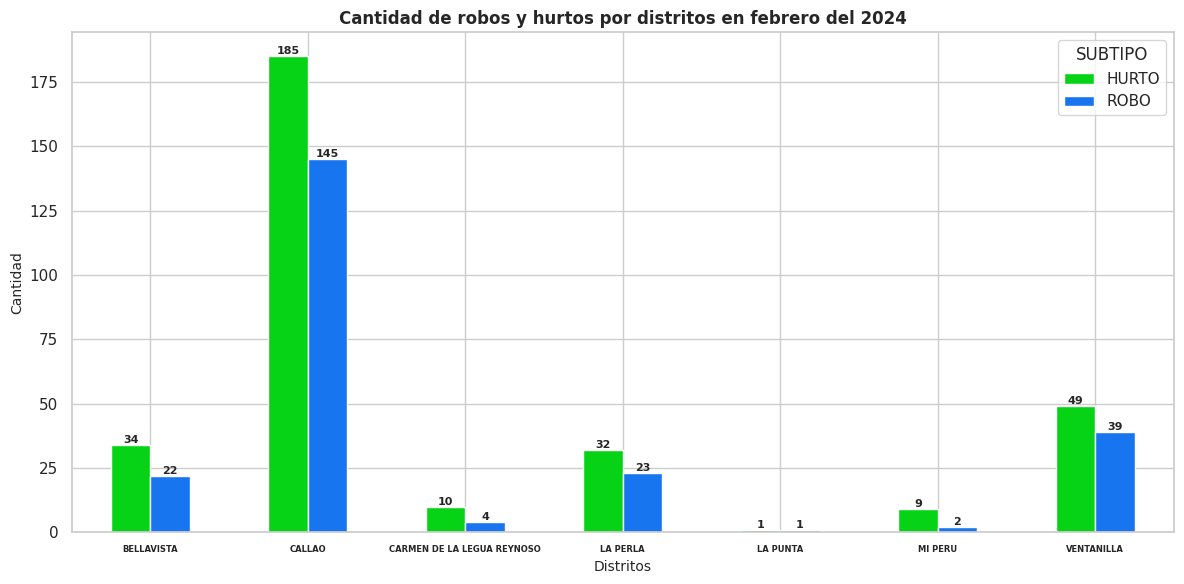

In [ ]:
# Creao el gráfico de barras
ax = tabla.plot(kind='bar', figsize=(12, 6), color=['#07d316', '#1875f0'])

# Personalizo el gráfico
plt.title('Cantidad de robos y hurtos por distritos en febrero del 2024', fontweight='bold')
plt.xlabel('Distritos', fontsize=10)
plt.ylabel('Cantidad', fontsize=10)
plt.xticks(rotation=0, fontsize=6, fontweight='bold')  # Rotar los nombres de los distritos si es necesario

# Añado etiquetas encima de las barras con tamaño de fuente reducido
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(str(int(height)),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, fontweight='bold')  # Cambia 'fontsize' a 8 para reducir el tamaño

# Aumento el tamaño de la fuente para las palabras 'HURTO' y 'ROBO'
for label in ax.get_xticklabels():
    if 'ROBO' in label.get_text() or 'HURTO' in label.get_text():
        label.set_fontsize(14)

# Muestro el gráfico
plt.legend(title='SUBTIPO')
plt.tight_layout()  # Ajustar el diseño para que se vea bien
plt.show()


En el gráfico superior se visualiza de mejor manera el análisis, en donde se nota con claridad los distritos que poseen mayor denuncia de delitos por robo y hurto.

In [ ]:
data2.MODALIDAD.unique()

In [ ]:
df2_filtered = data2[(data2['SUBTIPO'] == 'HURTO') | (data2['SUBTIPO'] == 'ROBO')]

# Seleccionamos solo las columnas que te interesan
df2_filtered.groupby(['SUBTIPO', 'MODALIDAD']).size().unstack(fill_value=0)

MODALIDAD,ASALTO Y ROBO DE VEHICULOS,HURTO,HURTO AGRAVADO,HURTO AGRAVADO DURANTE LA NOCHE,HURTO AGRAVADO EN CASA HABITADA,HURTO DE ACCESORIOS Y AUTOPARTES DE VEHICULOS,HURTO DE CELULAR,HURTO DE VEHICULO,HURTO FRUSTRADO,ROBO,ROBO AGRAVADO,ROBO AGRAVADO A MANO ARMADA,ROBO AGRAVADO DURANTE LA NOCHE O EN LUGAR DESOLADO,ROBO AGRAVADO EN BANDA,ROBO DE CELULAR,TENTATIVA DE ROBO
SUBTIPO,,,,,,,,,,,,,,,,
HURTO,0,134,76,9,9,25,29,37,1,0,0,0,0,0,0,0
ROBO,10,0,0,0,0,0,0,0,0,76,100,32,6,2,7,3


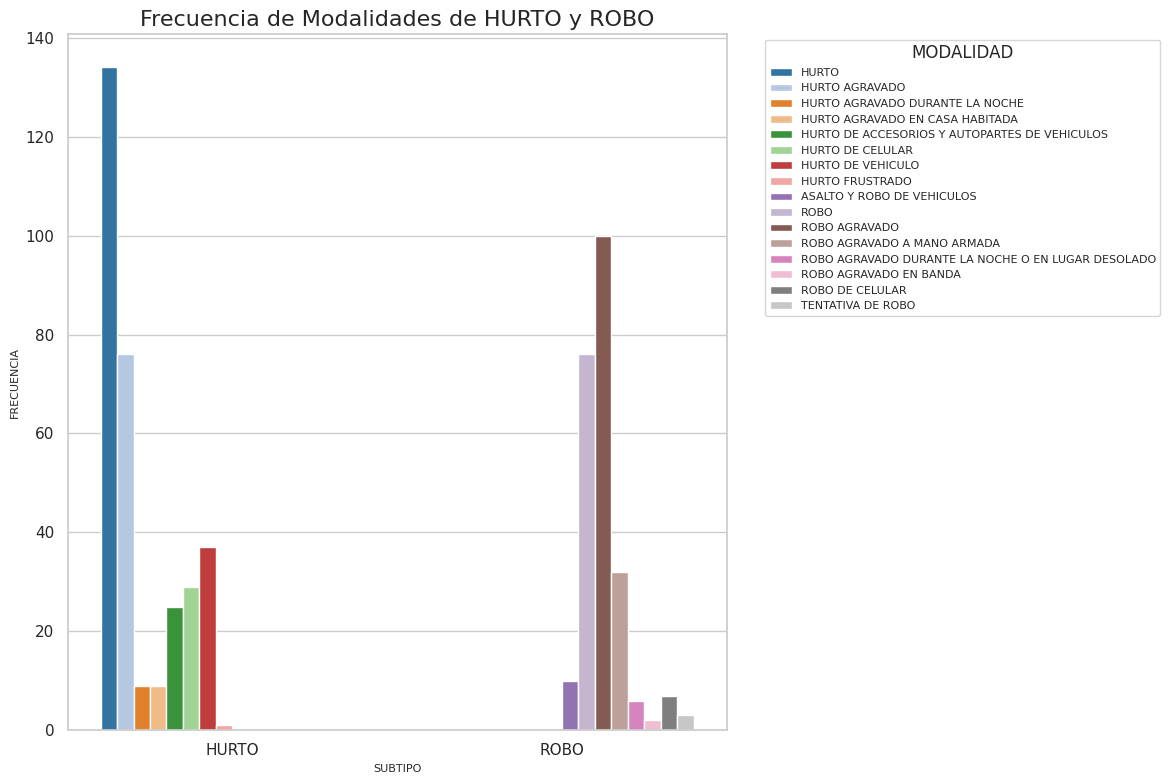

In [ ]:
# Contamos las combinaciones de SUBTIPO y MODALIDAD
df_counts = df2_filtered.groupby(['SUBTIPO', 'MODALIDAD']).size().reset_index(name='counts')

# Configuramos el estilo de Seaborn
sns.set(style="whitegrid")

# Creamos el gráfico de barras
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='SUBTIPO',
    y='counts',
    hue='MODALIDAD',
    data=df_counts,
    palette='tab20'
)

# Movemos la leyenda a un lugar adecuado y ajustamos el tamaño de la fuente
ax.legend(title='MODALIDAD', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize='medium')

# Añadimos un título y etiquetas a los ejes
plt.title('Frecuencia de Modalidades de HURTO y ROBO', fontsize=16)
plt.xlabel('SUBTIPO', fontsize=8)
plt.ylabel('FRECUENCIA', fontsize=8)

# Ajustamos el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()


A continuación se muestra el gráfico con las cantidades de denuncias respectivas:

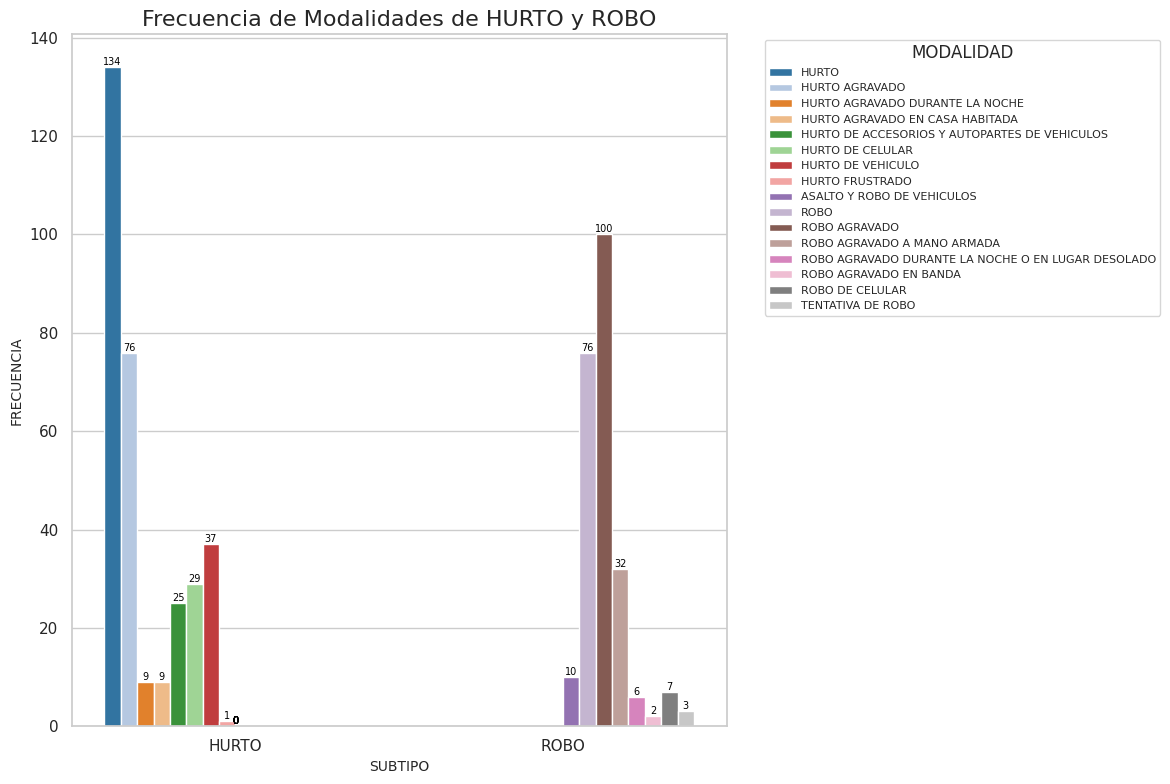

In [ ]:
# Contamos las combinaciones de SUBTIPO y MODALIDAD
df_counts = df2_filtered.groupby(['SUBTIPO', 'MODALIDAD']).size().reset_index(name='counts')

# Configuramos el estilo de Seaborn
sns.set(style="whitegrid")

# Creamos el gráfico de barras
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='SUBTIPO',
    y='counts',
    hue='MODALIDAD',
    data=df_counts,
    palette='tab20'
)

# Añadimos números sobre las barras
for p in ax.patches:
    # Agregamos el texto sobre cada barra
    ax.annotate(
        format(p.get_height(), '.0f'),  # Formato del número sin decimales
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Coordenadas del texto
        ha='center',
        va='bottom',
        fontsize=7,  # Tamaño de la fuente
        color='black'  # Color del texto
    )

# Movemos la leyenda a un lugar adecuado y ajustamos el tamaño de la fuente
ax.legend(title='MODALIDAD', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize='medium')

# Añadimos un título y etiquetas a los ejes
plt.title('Frecuencia de Modalidades de HURTO y ROBO', fontsize=16)
plt.xlabel('SUBTIPO', fontsize=10)
plt.ylabel('FRECUENCIA', fontsize=10)

# Ajustamos el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()


En el gráfico superior, se observa que las modalidades de denuncias de hurto más frecuentes en el mes de febrero de 2024 son el hurto (134 denuncias), el hurto agravado (76 denuncias)y el hurto de vehículo (37 denuncias), seguidos de hurto de celular y hurto de accesorios o artefactos de vehículos (29 y 25 denuncias respectivamente). En cuanto a los robos, las modalidades más frecuentes son el robo agravado (100 denuncias), el robo (76 denuncias) y el robo agravado a mano armada (32 denuncias) seguidos por asalto y robo de vehículos (10 denuncias) y robo de celular (7 denuncias), ordenadas de mayor a menor según el número de denuncias.

## **4. CONCLUSIONES**



*  Las denuncias por robo y hurto ocuparon el segundo y tercer lugar en número de casos durante febrero de 2024, lo que indica que, además de la violencia contra la mujer y la familia, estos delitos requieren especial atención. Además, son crímenes a los que la población está constantemente expuesta en su vida cotidiana.

*  Las modalidades mas comunes identificadas en el mes de febrero del 2024 son hurto, hurto agravado, hurto de vehículo, robo agravado, robo y robo de vehículos.

* El distrito del Callao y el distrito de Ventanilla son los que presentan la mayor cantidad de denuncias en el mes de febrero de 2024.


## **5. PROPUESTA DE SOLUCIÓN**

La solución que planteamos es el desarrollo de  una aplicación móvil que notifique a los usuarios cuando se acerquen a zonas con alta incidencia de robo, hurto y homicidio en el Callao. La app utiliza un mapa de calor generado en QGIS y envía alertas en tiempo real basadas en la ubicación del usuario. Esta aplicación está diseñada para ser escalable y compatible con múltiples plataformas, usando Kotlin Multiplatform (Android e iOS). Esta app tendrá la funcionalidad de alertar al usuario mediante notificaciones descritas. Además, la app está proyectada a incorporar inteligencia basada en lenguaje natural, lo que permitirá automatizar y contextualizar las notificaciones que el usuario reciba, si en algún momento se desea implementar a futuro. Además,  proporcionará información relevante sobre los delitos de robo, hurto y homicidio ocurridos históricamente en la zona hacia la que se dirige el usuario, mejorando así la precaución del ciudadano.

La aplicación ha iniciado recientemente su desarrollo del cual se implementará todas las funcionalidades para mostrar el mapa de calor correspondiente e integrar las notificaciones a un usuario registrado en nuestra app. Como ejemplo se colocó el nombre de la app como "Guardián Urbano Perú". A continuación se muestra una captura del mismo.

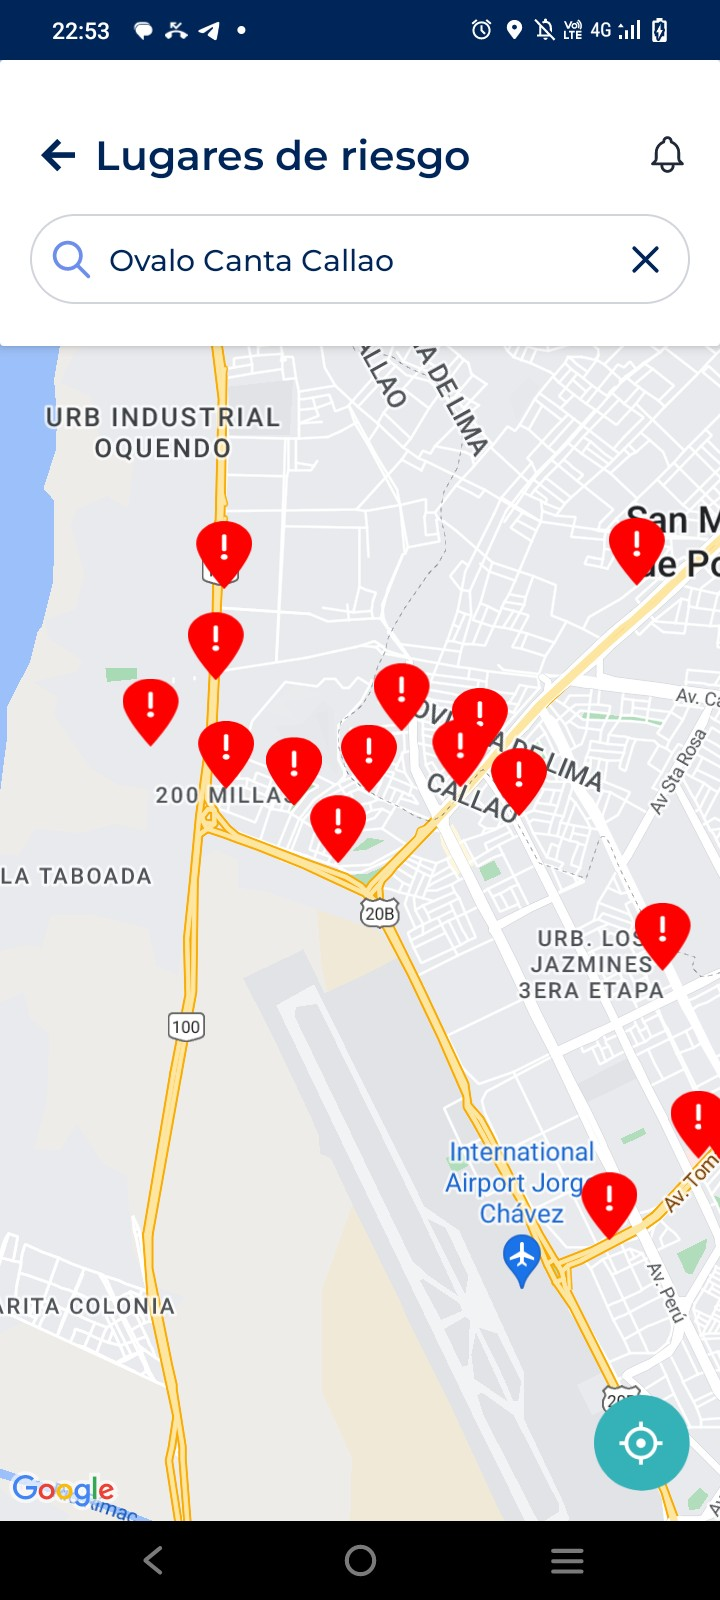

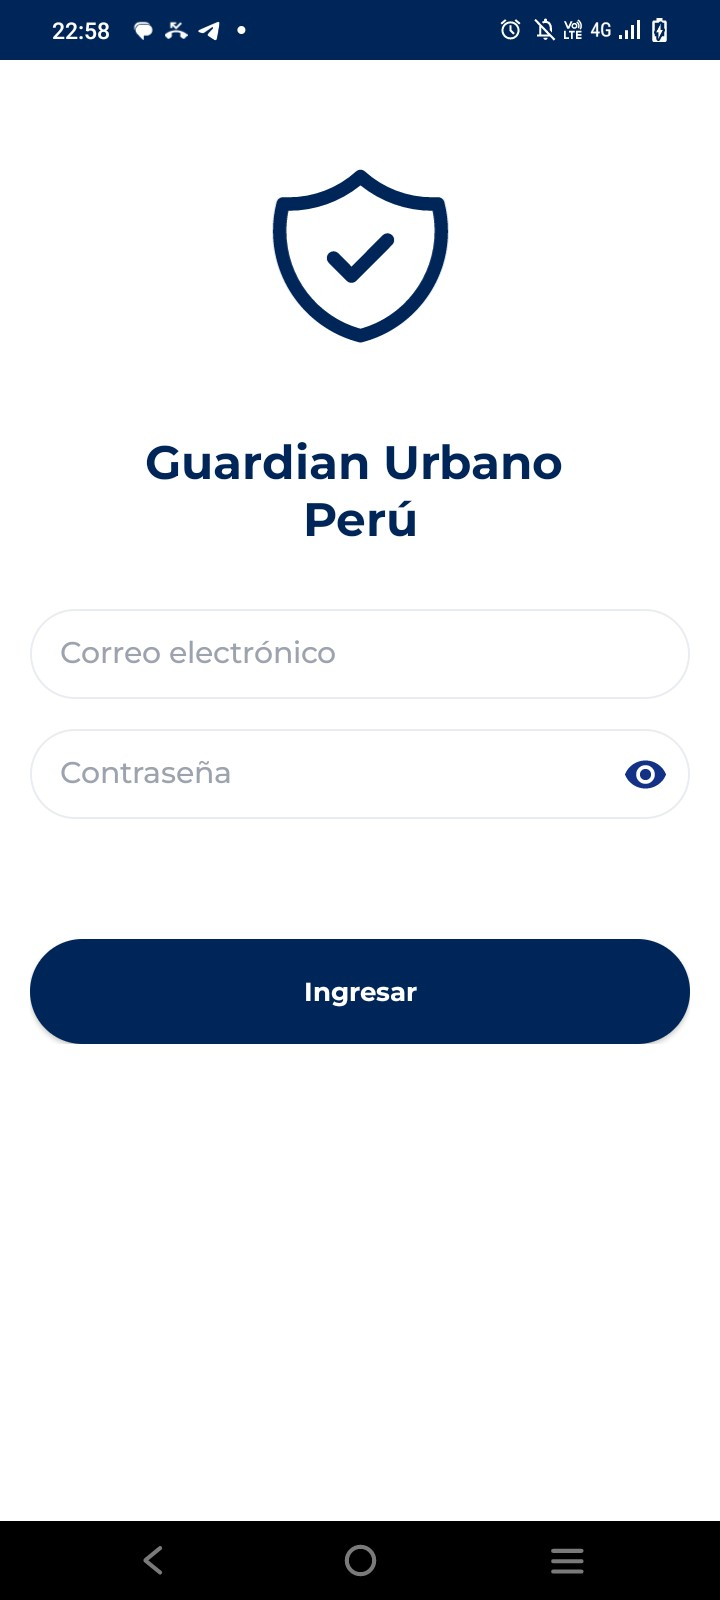